<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
ciudades=pd.read_csv("base_conresnet.csv")

In [11]:
num_valores = ciudades['Desigualdad_10km'].count()
print(f"Número de valores no nulos en 'Desigualdad_10km': {num_valores}")

Número de valores no nulos en 'Desigualdad_10km': 1095


In [19]:
top_ciudades = ciudades.nsmallest(10, 'Desigualdad_10km')

# Obtener los valores de la columna 'City'
top_ciudades_list = top_ciudades['City'].tolist()

print(top_ciudades_list)

['HO: Copan-La Union', 'HO: Comayagua-Siguatepeque', 'SV: Chalatenango-Tejutla', 'GT: Guatemala-Palencia', 'DO: San Cristobal-Cambita Garabito', 'CR: Puntarenas-Coto Brus', 'SV: Chalatenango-Chalatenango', 'CR: Heredia-San Rafael', 'HO: Lempira-Gracias', 'BR: Norte-Para-Sao Felix do Xingu']


# Gráficos y Regresiones

In [13]:
import statsmodels.api as sm
import numpy as np

# Definir variables
X = ciudades["Desigualdad_1km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     8.008
Date:                Sun, 30 Mar 2025   Prob (F-statistic):            0.00474
Time:                        00:39:58   Log-Likelihood:                -484.01
No. Observations:                1095   AIC:                             972.0
Df Residuals:                    1093   BIC:                             982.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.2529      0.051     

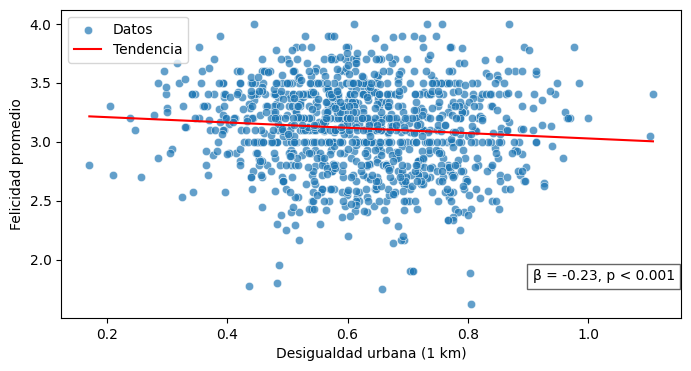

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir coeficientes de la regresión
intercept = 3.2529
slope = -0.2262
p_value = "< 0.001"  # Significancia del coeficiente

# Calcular valores ajustados para la línea de tendencia
x_vals = np.linspace(ciudades["Desigualdad_1km"].min(), ciudades["Desigualdad_1km"].max(), 100)
y_vals = intercept + slope * x_vals  # Ecuación de la regresión

# Crear la figura
plt.figure(figsize=(8, 4))

# Graficar los datos (X = desigualdad, Y = felicidad)
sns.scatterplot(data=ciudades, x="Desigualdad_1km", y="P1ST", alpha=0.7, label="Datos")

# Graficar la línea de tendencia correctamente orientada
plt.plot(x_vals, y_vals, color="red", label=f"Tendencia")

# Agregar información sobre la significancia del coeficiente en el gráfico
plt.text(ciudades["Desigualdad_1km"].max()-0.2, ciudades["P1ST"].min()+0.2, f"β = {slope:.2f}, p {p_value}",
         fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.6))

# Etiquetas y título
plt.xlabel("Desigualdad urbana (1 km)")
plt.ylabel("Felicidad promedio")
#plt.title("Relación entre desigualdad urbana y felicidad")
plt.legend()

# Mostrar el gráfico
plt.show()

In [21]:
# Definir variables
X = ciudades["Desigualdad_10km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     42.75
Date:                Sun, 30 Mar 2025   Prob (F-statistic):           9.52e-11
Time:                        00:58:01   Log-Likelihood:                -467.00
No. Observations:                1095   AIC:                             938.0
Df Residuals:                    1093   BIC:                             948.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.3968      0.045  

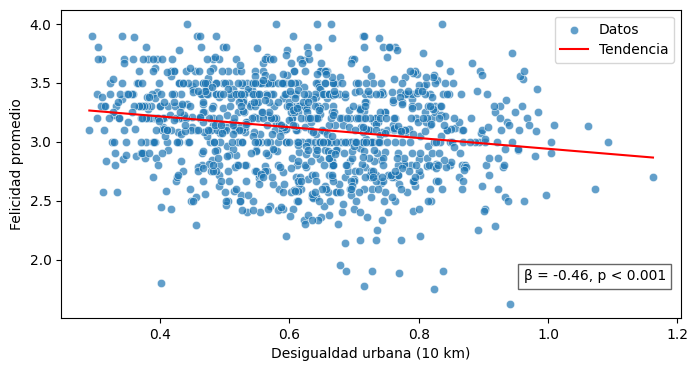

In [22]:
# Definir coeficientes de la regresión
intercept = 3.3968
slope = -0.4576
p_value = "< 0.001"  # Significancia del coeficiente

# Calcular valores ajustados para la línea de tendencia
x_vals = np.linspace(ciudades["Desigualdad_10km"].min(), ciudades["Desigualdad_10km"].max(), 100)
y_vals = intercept + slope * x_vals  # Ecuación de la regresión

# Crear la figura
plt.figure(figsize=(8, 4))

# Graficar los datos (X = desigualdad, Y = felicidad)
sns.scatterplot(data=ciudades, x="Desigualdad_10km", y="P1ST", alpha=0.7, label="Datos")

# Graficar la línea de tendencia correctamente orientada
plt.plot(x_vals, y_vals, color="red", label=f"Tendencia")

# Agregar información sobre la significancia del coeficiente en el gráfico
plt.text(ciudades["Desigualdad_10km"].max()-0.2, ciudades["P1ST"].min()+0.2, f"β = {slope:.2f}, p {p_value}",
         fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.6))

# Etiquetas y título
plt.xlabel("Desigualdad urbana (10 km)")
plt.ylabel("Felicidad promedio")
#plt.title("Relación entre desigualdad urbana y felicidad")
plt.legend()

# Mostrar el gráfico

plt.show()

# Placebo Test

In [23]:
ciudades["placebo_felicidad"] = np.random.randint(1,5, size=len(ciudades))
ciudades["placebo_desigualdad"] = np.random.uniform(ciudades["Desigualdad_1km"].min(), ciudades["Desigualdad_1km"].max(), size=len(ciudades))

In [24]:
# Definir variables
X = ciudades["placebo_desigualdad"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.05623
Date:                Sun, 30 Mar 2025   Prob (F-statistic):              0.813
Time:                        00:58:33   Log-Likelihood:                -487.97
No. Observations:                1095   AIC:                             979.9
Df Residuals:                    1093   BIC:                             989.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.1053    

# Submuestras

In [ ]:
latino=pd.read_stata('/content/Latinobarometro_2023_Esp_Stata_v1_0.dta')

conversion = {
    "No muy satisfecho": 2,
    "Para nada satisfecho": 1,
    "Bastante satisfecho": 3,
    "Muy satisfecho": 4
}

# Reemplazar valores en la columna P1ST
latino["felicidad"] = latino["P1ST"].map(conversion)

In [ ]:
latino.P61ST=latino.P61ST.replace('01 Completamente inaceptable',1).replace('10 Completamente aceptable',10).replace('No sabe',np.nan).replace('No contesta',np.nan).astype(float)

<ipython-input-154-85a1ff755002>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  latino.P61ST=latino.P61ST.replace('01 Completamente inaceptable',1).replace('10 Completamente aceptable',10).replace('No sabe',np.nan).replace('No contesta',np.nan).astype(float)


In [ ]:
# Suponiendo que 'latino' es tu DataFrame
columnas = ['S14M_A', 'S14M_B', 'S14M_C', 'S14M_D', 'S14M_E', 'S14M_F', 'S14M_G', 'S14M_H']

latino['redes'] = latino[columnas].apply(lambda row: 1 if 'Menciona' in row.values else 0, axis=1)

In [ ]:
latino["S5"] = latino["S5"].replace({
    'No les alcanza, tienen grandes dificultades': 0,
    'No les alcanza, tienen dificultades': 1,
    'Les alcanza justo, sin grandes dificultades': 2,
    'Les alcanza bien, pueden ahorrar': 3,
    'No sabe': np.nan,
    'No contesta': np.nan
}).astype(float)

<ipython-input-156-d233daf810fc>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  latino["S5"] = latino["S5"].replace({
<ipython-input-156-d233daf810fc>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  latino["S5"] = latino["S5"].replace({


In [ ]:
latino["ingreso_subjetivo"]=latino["S5"]
latino["aceptacion_desigualdad"]=latino["P61ST"]

In [ ]:
# Diccionario de mapeo para asignar valores numéricos según los años de estudio
years_map = {
    "12 anos": 12,
    "Universitario completo": 16,  # Suponiendo que la educación universitaria completa es equivalente a 16 años
    "Instituto superior/academias/Formacion tecnica completa": 14,
    "10 anos": 10,
    "11 anos": 11,
    "7 anos": 7,
    "Universitario incompleto": 14,  # Suposición de 14 años
    "Instituto superior/academias/Formacion tecnica incompleta": 13,
    "9 anos": 9,
    "6 anos": 6,
    "8 anos": 8,
    "Sin estudios": 0,  # Si no tiene estudios, se asigna 0 años
    "3 anos": 3,
    "5 anos": 5,
    "1 ano": 1,
    "4 anos": 4,
    "2 anos": 2
}

# Crear una nueva variable con los años de estudio
latino['años_estudio'] = latino['S11'].map(years_map)

In [ ]:
mapa_conversion = {
    'Muy injusta': 1,
    'Injusta': 2,
    'Justa': 3,
    'Muy justa': 4,
    'No sabe': np.nan,
    'No contesta': np.nan
}

# Convertir la columna P17ST a valores float según el diccionario
latino['desigualdad_subjetiva'] = latino['P17ST'].map(mapa_conversion)

In [ ]:
latino=latino.groupby("ciudad", as_index=False, observed=True).agg({
    "felicidad": "mean",
    "aceptacion_desigualdad": "mean",
    "redes": "mean",
    "ingreso_subjetivo": "mean",
    "desigualdad_subjetiva": "mean",
    "años_estudio": "mean",
    "tamciud": "first"  # Mantiene el primer valor de tamciud por ciudad
})

In [ ]:
ciudades=ciudades.merge(latino, left_on="City", right_on="ciudad", how="left")

In [ ]:
# Corre la variable de desigualdad creada por imagenes satelitales contra la variable sibjetiva de desigualdad

import statsmodels.api as sm
import numpy as np

# Definir variables
X = ciudades["Desigualdad_10km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["aceptacion_desigualdad"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                              OLS Regression Results                              
Dep. Variable:     aceptacion_desigualdad   R-squared:                       0.036
Model:                                OLS   Adj. R-squared:                  0.035
Method:                     Least Squares   F-statistic:                     40.76
Date:                    Fri, 28 Mar 2025   Prob (F-statistic):           2.54e-10
Time:                            19:15:40   Log-Likelihood:                -2001.7
No. Observations:                    1093   AIC:                             4007.
Df Residuals:                        1091   BIC:                             4017.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


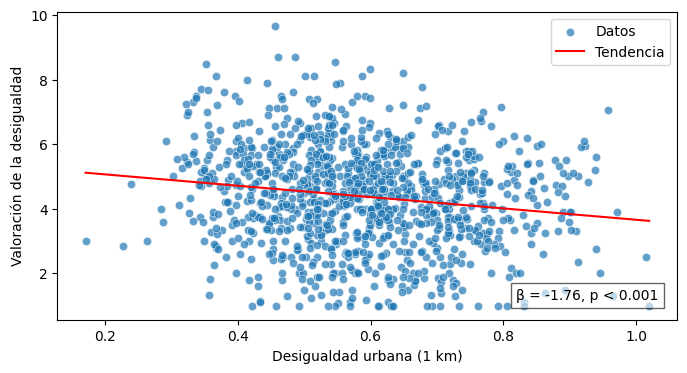

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir coeficientes de la regresión
intercept = 5.4177
slope = -1.7575
p_value = "< 0.001"  # Significancia del coeficiente

# Calcular valores ajustados para la línea de tendencia
x_vals = np.linspace(ciudades["Desigualdad_1km"].min(), ciudades["Desigualdad_1km"].max(), 100)
y_vals = intercept + slope * x_vals  # Ecuación de la regresión

# Crear la figura
plt.figure(figsize=(8, 4))

# Graficar los datos (X = desigualdad, Y = felicidad)
sns.scatterplot(data=ciudades, x="Desigualdad_1km", y="aceptacion_desigualdad", alpha=0.7, label="Datos")

# Graficar la línea de tendencia correctamente orientada
plt.plot(x_vals, y_vals, color="red", label=f"Tendencia")

# Agregar información sobre la significancia del coeficiente en el gráfico
plt.text(ciudades["Desigualdad_1km"].max()-0.2, ciudades["aceptacion_desigualdad"].min()+0.2, f"β = {slope:.2f}, p {p_value}",
         fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.6))

# Etiquetas y título
plt.xlabel("Desigualdad urbana (1 km)")
plt.ylabel("Valoración de la desigualdad")
#plt.title("Relación entre desigualdad urbana y felicidad")
plt.legend()

# Mostrar el gráfico

plt.show()

In [ ]:
import numpy as np
import statsmodels.api as sm

# Filtrar las ciudades según el tamaño
ciudades_filtradas = ciudades[ciudades["tamciud"].isin(["(Capital)", "100.001 y más"])]

# Definir variables
X = ciudades_filtradas["Desigualdad_1km"].replace([np.inf, -np.inf], np.nan)
y = ciudades_filtradas["aceptacion_desigualdad"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                              OLS Regression Results                              
Dep. Variable:     aceptacion_desigualdad   R-squared:                       0.013
Model:                                OLS   Adj. R-squared:                  0.001
Method:                     Least Squares   F-statistic:                     1.043
Date:                    Fri, 28 Mar 2025   Prob (F-statistic):              0.310
Time:                            19:15:40   Log-Likelihood:                -146.54
No. Observations:                      81   AIC:                             297.1
Df Residuals:                          79   BIC:                             301.9
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
co

In [ ]:
ciudades["capital"] = np.where(ciudades["tamciud"].isin(["(Capital)", "100.001 y más"]), 1, 0)

In [ ]:
# Corre el modelo con varios regresores

# Definir variables
X = ciudades[["Desigualdad_1km", "Desigualdad_10km", "redes", "aceptacion_desigualdad", "ingreso_subjetivo", "capital", "años_estudio", "desigualdad_subjetiva"]].replace([np.inf, -np.inf], np.nan)
y = ciudades["felicidad"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:              felicidad   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     16.43
Date:                Fri, 28 Mar 2025   Prob (F-statistic):           4.10e-23
Time:                        19:15:54   Log-Likelihood:                -425.39
No. Observations:                1093   AIC:                             868.8
Df Residuals:                    1084   BIC:                             913.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2